In [1]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [2]:
# Model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# model metrics libraries

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, 
    classification_report
    )

In [3]:
# Get the absolute path of the directory one level up (project root)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add it to sys.path if it's not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# import SoilDataPreprocessor
from api.utils.preprocessing import SoilDataPreprocessor

In [4]:
# read data from the cleaned sheet
df_clean = pd.read_csv('../data/data_for_fertilizer_classification.csv')

# preview of the first 10 rows of the dataframe
df_clean.head(10)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus,croprecommendation1,croprecommendation2,fertilizerrecommendation1,fertilizerrecommendation2
0,SILTY SOIL,4.9,0.14,22.9,0.14,1.1,1.3,2.2,1.2,10.1,5.6,VERY POOR,CASSAVA,COTTON,NPK,NPK
1,LOAMY SOIL,5.7,0.14,28.3,0.27,1.3,1.8,2.1,1.2,12.9,5.2,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
2,SILTY LOAM,5.9,0.16,23.1,0.39,2.1,1.6,2.5,1.2,10.1,6.4,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
3,LOAMY SOIL,5.7,0.20,29.2,0.47,2.1,2.8,2.2,1.2,12.0,7.4,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
4,LOAM,5.7,0.14,28.3,0.28,2.2,3.2,1.4,1.2,12.3,7.0,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
5,SILTY SAND,5.7,0.17,29.2,0.72,2.0,2.4,1.9,1.2,11.2,10.3,MODERATELY HEALTHY,SOYBEAN,SESAME,NPK,NPK
6,SILT,5.9,0.18,27.2,0.18,1.9,2.7,2.0,1.4,13.1,5.9,MODERATELY HEALTHY,BEANS,MAIZE,NPK,TSP
7,LOAM,5.7,0.16,22.9,1.22,1.2,2.2,1.5,1.7,12.4,9.4,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
8,LOAMY SILT,5.6,0.15,19.4,0.72,1.3,1.9,2.2,1.2,12.6,8.7,POOR,BANANA,ALVS,NPK,NPK
9,LOAM,5.4,0.14,23.2,1.21,1.4,1.1,2.1,1.1,12.9,6.8,POOR,MAIZE,BEANS,NPK,TSP


In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   simpliedtexture(1)         1000 non-null   object 
 1   ph                         1000 non-null   float64
 2   n                          1000 non-null   float64
 3   p                          1000 non-null   float64
 4   k                          1000 non-null   float64
 5   o                          1000 non-null   float64
 6   ca                         1000 non-null   float64
 7   mg                         1000 non-null   float64
 8   cu                         1000 non-null   float64
 9   fe                         1000 non-null   float64
 10  zn                         1000 non-null   float64
 11  soilfertilitystatus        1000 non-null   object 
 12  croprecommendation1        1000 non-null   object 
 13  croprecommendation2        1000 non-null   object

In [6]:
# Function to convert object columns to categorical
def convert_objects_to_categorical(df):
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')
    return df

# Convert object columns to categorical
df_clean = convert_objects_to_categorical(df_clean)

In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   simpliedtexture(1)         1000 non-null   category
 1   ph                         1000 non-null   float64 
 2   n                          1000 non-null   float64 
 3   p                          1000 non-null   float64 
 4   k                          1000 non-null   float64 
 5   o                          1000 non-null   float64 
 6   ca                         1000 non-null   float64 
 7   mg                         1000 non-null   float64 
 8   cu                         1000 non-null   float64 
 9   fe                         1000 non-null   float64 
 10  zn                         1000 non-null   float64 
 11  soilfertilitystatus        1000 non-null   category
 12  croprecommendation1        1000 non-null   category
 13  croprecommendation2        1000 no

In [8]:
df_clean["croprecommendation1"].value_counts() # 15 classes

croprecommendation1
ALVS           176
SESAME         175
MAIZE          145
COTTON         109
CASSAVA         91
SOYBEAN         76
MILLET          42
BANANA          39
SORGHUM         39
BEANS           36
SUNFLOWER       36
PEANUT          16
PINEAPPLE       10
PAWPAW           6
ARROW ROOTS      4
Name: count, dtype: int64

In [9]:
df_clean["croprecommendation2"].value_counts() # 12 classes

croprecommendation2
BANANA       176
SOYBEAN      174
BEANS        145
CASSAVA      113
COTTON        91
SESAME        76
MILLET        75
ALVS          45
SORGHUM       43
MAIZE         36
PINEAPPLE     16
PEANUT        10
Name: count, dtype: int64

In [10]:
df_clean.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'croprecommendation1',
       'croprecommendation2', 'fertilizerrecommendation1',
       'fertilizerrecommendation2'],
      dtype='object')

In [11]:
# Drop the fertilizer recommendation column
df_clean = df_clean.drop(columns=["fertilizerrecommendation1", "fertilizerrecommendation2"])
df_clean.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'croprecommendation1',
       'croprecommendation2'],
      dtype='object')

In [12]:
# Separate the crop recommendation 1 and crop recommendation 2

# 1. Crop recommendation 1
df_crop_recommend_1 = df_clean.copy()

# 2. Crop recommendation 2
df_crop_recommend_2 = df_clean.copy()

#### Crop Recommendation 1

In [13]:
df_crop_recommend_1.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'croprecommendation1',
       'croprecommendation2'],
      dtype='object')

In [14]:
df_crop_recommend_1 = df_crop_recommend_1.drop(columns=["croprecommendation2"])
df_crop_recommend_1.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'croprecommendation1'],
      dtype='object')

In [15]:
df_crop_recommend_1["croprecommendation1"].value_counts()

croprecommendation1
ALVS           176
SESAME         175
MAIZE          145
COTTON         109
CASSAVA         91
SOYBEAN         76
MILLET          42
BANANA          39
SORGHUM         39
BEANS           36
SUNFLOWER       36
PEANUT          16
PINEAPPLE       10
PAWPAW           6
ARROW ROOTS      4
Name: count, dtype: int64

In [16]:
preprocessor_1 = SoilDataPreprocessor()

train_data_processed_crop_1 = preprocessor_1.fit_transform(
    df_crop_recommend_1, 
    target_column='croprecommendation1',
    encoding_type='label',
    scaling_type='standard',
    apply_smote=True # Change to False and handle class imbalance using the models class_weight parameter 
)

2026-01-28 00:13:32,763 - SoilDataPreprocessor - INFO - SoilDataPreprocessor initialized
2026-01-28 00:13:32,768 - SoilDataPreprocessor - INFO - ============================================================
2026-01-28 00:13:32,774 - SoilDataPreprocessor - INFO - Starting fit_transform process
2026-01-28 00:13:32,778 - SoilDataPreprocessor - INFO - Parameters - encoding: label, scaling: standard, SMOTE: True
2026-01-28 00:13:32,782 - SoilDataPreprocessor - INFO - Input DataFrame shape: (1000, 13)
2026-01-28 00:13:32,791 - SoilDataPreprocessor - INFO - Target column: croprecommendation1
2026-01-28 00:13:32,793 - SoilDataPreprocessor - INFO - Target column data type: category
2026-01-28 00:13:32,802 - SoilDataPreprocessor - INFO - Target classes: ['CASSAVA', 'BANANA', 'SOYBEAN', 'BEANS', 'MAIZE', ..., 'SESAME', 'SUNFLOWER', 'PINEAPPLE', 'COTTON', 'PAWPAW']
Length: 15
Categories (15, object): ['ALVS', 'ARROW ROOTS', 'BANANA', 'BEANS', ..., 'SESAME', 'SORGHUM', 'SOYBEAN', 'SUNFLOWER']
Overal

In [17]:
df_crop_recommend_1["croprecommendation1"].value_counts()

croprecommendation1
ALVS           176
SESAME         175
MAIZE          145
COTTON         109
CASSAVA         91
SOYBEAN         76
MILLET          42
BANANA          39
SORGHUM         39
BEANS           36
SUNFLOWER       36
PEANUT          16
PINEAPPLE       10
PAWPAW           6
ARROW ROOTS      4
Name: count, dtype: int64

In [18]:
train_data_processed_crop_1['croprecommendation1'].value_counts()

croprecommendation1
4     176
2     176
13    176
3     176
6     176
0     176
7     176
9     176
1     176
12    176
11    176
14    176
10    176
5     176
8     176
Name: count, dtype: int64

In [19]:
# Save the fitted crop recommendation preprocessor
# preprocessor_1.save('../models/soil_crop_recommendation1_preprocessor.joblib')

In [20]:
train_data_processed_crop_1.head(10)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus,croprecommendation1
0,19,-1.314042,-0.062645,-0.425646,-2.831822,-0.184988,-0.779966,1.032378,-0.999140,-1.895471,-0.244818,2,4
1,9,0.062819,-0.062645,0.867893,-2.374031,0.096363,-0.472312,0.816037,-0.999140,1.283516,-0.478647,0,2
2,17,0.407035,-0.035079,-0.377738,-1.951455,1.221765,-0.595373,1.681400,-0.999140,-1.895471,0.222838,0,2
3,9,0.062819,0.020055,1.083483,-1.669738,1.221765,0.142998,1.032378,-0.999140,0.261699,0.807409,0,2
4,3,0.062819,-0.062645,0.867893,-2.338816,1.362440,0.389122,-0.698348,-0.999140,0.602305,0.573581,0,2
5,18,0.062819,-0.021295,1.083483,-0.789372,1.081089,-0.103126,0.383356,-0.999140,-0.646583,2.502665,0,13
6,14,0.407035,-0.007512,0.604394,-2.690963,0.940414,0.081467,0.599696,0.029311,1.510587,-0.069447,0,3
7,3,0.062819,-0.035079,-0.425646,0.971361,-0.044313,-0.226188,-0.482007,1.571987,0.715840,1.976551,0,2
8,8,-0.109288,-0.048862,-1.264052,-0.789372,0.096363,-0.410781,1.032378,-0.999140,0.942910,1.567351,1,2
9,3,-0.453504,-0.062645,-0.353783,0.936146,0.237038,-0.903028,0.816037,-1.513365,1.283516,0.456667,1,6


In [21]:
from sklearn.model_selection import train_test_split

X = train_data_processed_crop_1.drop(columns=['croprecommendation1'])
y = train_data_processed_crop_1['croprecommendation1']

print(f"X columns used: \n", X.columns)
print(f"\ny target columns:", y.name)

# splitting the dataset into train , test and validation
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, test_size=0.25, random_state=43)

X columns used: 
 Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus'],
      dtype='object')

y target columns: croprecommendation1


In [22]:
# Random forest classifier for crop recommendation 1

# Initialize the Random Forest Classifier
rf_1 = RandomForestClassifier(class_weight='balanced_subsample', random_state=142)

# Fit the model
rf_1.fit(X_train_1, y_train_1)

# Make predictions on test set
y_pred_rf_1 = rf_1.predict(X_test_1)

In [23]:
# Model Evaluation for Random Forest
print("\nRandom Forest:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test_1, y_pred_rf_1):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test_1, y_pred_rf_1, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test_1, y_pred_rf_1, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall.
print(f"F1 Score: {f1_score(y_test_1, y_pred_rf_1, average='macro'):.4f}")


Random Forest:
Accuracy: 0.7742
Precision: 0.7705
Recall: 0.7915
F1 Score: 0.7680


In [24]:
print("Classification report:\n", classification_report(y_test_1, y_pred_rf_1))

Classification report:
               precision    recall  f1-score   support

           0       0.53      0.43      0.48        46
           1       0.92      1.00      0.96        48
           2       0.85      0.95      0.90        37
           3       0.79      0.94      0.86        48
           4       0.75      0.91      0.82        43
           5       0.45      0.72      0.55        40
           6       0.57      0.25      0.35        48
           7       0.84      0.86      0.85        44
           8       0.95      1.00      0.98        41
           9       0.88      1.00      0.94        38
          10       1.00      1.00      1.00        43
          11       0.58      0.25      0.35        56
          12       0.81      0.90      0.85        39
          13       0.67      0.77      0.72        44
          14       0.95      0.89      0.92        45

    accuracy                           0.77       660
   macro avg       0.77      0.79      0.77       660
we

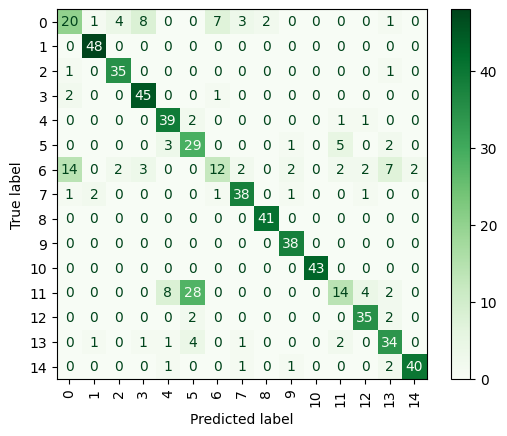

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_1, y_pred_rf_1, labels=rf_1.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_1.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

plt.show()

In [26]:
import joblib

# Save the model to a file

# joblib.dump(rf_1, "../models/Crop_recommendation_1_randomForest_Classifier_Model.joblib")

# print("Random Forest Classifier saved to: models/Crop_recommendation_1_randomForest_Classifier")

In [27]:
from sklearn.model_selection import RandomizedSearchCV

In [31]:
# 1. Define the parameter grid
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]

# Number of features to consider at every split
max_features = ['sqrt', 'log2', None]

# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)

# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]

# Method of selecting samples for training each tree
bootstrap = [True, False]

In [32]:
# Create the random grid
random_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap
}

print(f"Random grid initialized with {len(n_estimators) * len(max_features) * len(max_depth) * len(min_samples_split) * len(min_samples_leaf) * len(bootstrap)} combinations.")

Random grid initialized with 6480 combinations.


In [33]:
# 2. Initialize the base model
rf = RandomForestClassifier(random_state=142)

# 3. Initialize RandomizedSearchCV
# n_iter=50 means we try 50 random combinations; cv=3 means 3-fold cross-validation
rf_random = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=random_grid, 
    n_iter=50, 
    cv=3, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1
)

# 4. Fit the model
print("\nStarting Random Search... (This might take a few minutes)")
rf_random.fit(X_train_1, y_train_1)


Starting Random Search... (This might take a few minutes)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END bootstrap=True, max_depth=40, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   2.1s
[CV] END bootstrap=True, max_depth=40, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   2.1s
[CV] END bootstrap=True, max_depth=40, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   2.1s
[CV] END bootstrap=False, max_depth=80, max_features=None, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   5.6s
[CV] END bootstrap=False, max_depth=80, max_features=None, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   5.5s
[CV] END bootstrap=False, max_depth=80, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time=   3.6s
[CV] END bootstrap=False, max_depth=80, max_features=No

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=142),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110,
                                                      None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=42, verbose=2)

In [34]:
# 5. Output the best parameters
print("\nBest Hyperparameters Found:")
print(rf_random.best_params_)


Best Hyperparameters Found:
{'n_estimators': 1400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 80, 'bootstrap': False}


In [35]:
# 6. Evaluate the tuned model
best_rf_1 = rf_random.best_estimator_
y_pred_tuned_1 = best_rf_1.predict(X_test_1)

print("\nTuned Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test_1, y_pred_tuned_1):.4f}")
print(f"Precision: {precision_score(y_test_1, y_pred_tuned_1, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test_1, y_pred_tuned_1, average='macro'):.4f}")
print(f"F1 Score: {f1_score(y_test_1, y_pred_tuned_1, average='macro'):.4f}")

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test_1, y_pred_tuned_1))


Tuned Random Forest Results:
Accuracy: 0.7818
Precision: 0.7745
Recall: 0.7981
F1 Score: 0.7775

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.53      0.50      0.52        46
           1       0.98      1.00      0.99        48
           2       0.85      0.92      0.88        37
           3       0.87      0.94      0.90        48
           4       0.76      0.91      0.83        43
           5       0.41      0.62      0.50        40
           6       0.50      0.21      0.29        48
           7       0.93      0.93      0.93        44
           8       0.95      1.00      0.98        41
           9       0.93      1.00      0.96        38
          10       1.00      1.00      1.00        43
          11       0.48      0.27      0.34        56
          12       0.82      0.92      0.87        39
          13       0.71      0.82      0.76        44
          14       0.89      0.93      0.91        45


In [36]:
# initialise the model
xgb_1 = XGBClassifier(random_state=142)

# Fit the model
xgb_1.fit(X_train_1, y_train_1)

# predict the test set
y_pred_xgb_1 = xgb_1.predict(X_test_1)

In [37]:
# Model Evaluation for XGBoost
print("\nGradient Boosting Machine (XGBoost):")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test_1, y_pred_xgb_1):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test_1, y_pred_xgb_1, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test_1, y_pred_xgb_1, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall.
print(f"F1 Score: {f1_score(y_test_1, y_pred_xgb_1, average='macro'):.4f}")


Gradient Boosting Machine (XGBoost):
Accuracy: 0.7348
Precision: 0.7321
Recall: 0.7465
F1 Score: 0.7357


In [38]:
#Save the model to a file

# joblib.dump(xgb_1, "../models/Crop_recommendation_1_xgb_Model.joblib")

# print("Random Forest Classifier saved to: models/Crop_recommendation_1_xgb_Model")

#### Crop Recommendation 2

In [39]:
df_crop_recommend_2.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'croprecommendation1',
       'croprecommendation2'],
      dtype='object')

In [40]:
df_crop_recommend_2 = df_crop_recommend_2.drop(columns=["croprecommendation1"])
df_crop_recommend_2.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'croprecommendation2'],
      dtype='object')

In [41]:
preprocessor_2 = SoilDataPreprocessor()

train_data_processed_crop_2 = preprocessor_2.fit_transform(
    df_crop_recommend_2, 
    target_column='croprecommendation2',
    encoding_type='label',
    scaling_type='standard',
    apply_smote=True
)

2026-01-28 00:20:41,709 - SoilDataPreprocessor - INFO - SoilDataPreprocessor initialized
2026-01-28 00:20:41,712 - SoilDataPreprocessor - INFO - ============================================================
2026-01-28 00:20:41,714 - SoilDataPreprocessor - INFO - Starting fit_transform process
2026-01-28 00:20:41,717 - SoilDataPreprocessor - INFO - Parameters - encoding: label, scaling: standard, SMOTE: True
2026-01-28 00:20:41,719 - SoilDataPreprocessor - INFO - Input DataFrame shape: (1000, 13)
2026-01-28 00:20:41,722 - SoilDataPreprocessor - INFO - Target column: croprecommendation2
2026-01-28 00:20:41,725 - SoilDataPreprocessor - INFO - Target column data type: category
2026-01-28 00:20:41,730 - SoilDataPreprocessor - INFO - Target classes: ['COTTON', 'ALVS', 'SESAME', 'MAIZE', 'BEANS', ..., 'PINEAPPLE', 'CASSAVA', 'MILLET', 'SOYBEAN', 'PEANUT']
Length: 12
Categories (12, object): ['ALVS', 'BANANA', 'BEANS', 'CASSAVA', ..., 'PINEAPPLE', 'SESAME', 'SORGHUM', 'SOYBEAN']
Overall Progres

In [42]:
df_crop_recommend_2["croprecommendation2"].value_counts()

croprecommendation2
BANANA       176
SOYBEAN      174
BEANS        145
CASSAVA      113
COTTON        91
SESAME        76
MILLET        75
ALVS          45
SORGHUM       43
MAIZE         36
PINEAPPLE     16
PEANUT        10
Name: count, dtype: int64

In [43]:
train_data_processed_crop_2['croprecommendation2'].value_counts()

croprecommendation2
4     176
0     176
9     176
5     176
2     176
1     176
10    176
8     176
3     176
6     176
11    176
7     176
Name: count, dtype: int64

In [44]:
# Save the fitted preprocessor
#preprocessor_2.save('../models/soil_crop_recommendation2_preprocessor.joblib')

In [45]:
train_data_processed_crop_2.head(10)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus,croprecommendation2
0,19,-1.314042,-0.062645,-0.425646,-2.831822,-0.184988,-0.779966,1.032378,-0.999140,-1.895471,-0.244818,2,4
1,9,0.062819,-0.062645,0.867893,-2.374031,0.096363,-0.472312,0.816037,-0.999140,1.283516,-0.478647,0,0
2,17,0.407035,-0.035079,-0.377738,-1.951455,1.221765,-0.595373,1.681400,-0.999140,-1.895471,0.222838,0,0
3,9,0.062819,0.020055,1.083483,-1.669738,1.221765,0.142998,1.032378,-0.999140,0.261699,0.807409,0,0
4,3,0.062819,-0.062645,0.867893,-2.338816,1.362440,0.389122,-0.698348,-0.999140,0.602305,0.573581,0,0
5,18,0.062819,-0.021295,1.083483,-0.789372,1.081089,-0.103126,0.383356,-0.999140,-0.646583,2.502665,0,9
6,14,0.407035,-0.007512,0.604394,-2.690963,0.940414,0.081467,0.599696,0.029311,1.510587,-0.069447,0,5
7,3,0.062819,-0.035079,-0.425646,0.971361,-0.044313,-0.226188,-0.482007,1.571987,0.715840,1.976551,0,0
8,8,-0.109288,-0.048862,-1.264052,-0.789372,0.096363,-0.410781,1.032378,-0.999140,0.942910,1.567351,1,0
9,3,-0.453504,-0.062645,-0.353783,0.936146,0.237038,-0.903028,0.816037,-1.513365,1.283516,0.456667,1,2


In [46]:
from sklearn.model_selection import train_test_split

X_2 = train_data_processed_crop_2.drop(columns=['croprecommendation2'])
y_2 = train_data_processed_crop_2['croprecommendation2']

print(f"X columns used: \n", X_2.columns)
print(f"\ny target columns:", y_2.name)

# splitting the dataset into train , test and validation
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.25, random_state=43)

X columns used: 
 Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus'],
      dtype='object')

y target columns: croprecommendation2


#### Modelling

In [47]:
# Random forest classifier for crop recommendation 2

# Initialize the Random Forest Classifier
rf_2 = RandomForestClassifier(random_state=142)

# Fit the model
rf_2.fit(X_train_2, y_train_2)

# Make predictions on test set
y_pred_rf_2 = rf_2.predict(X_test_2)

In [48]:
# Model Evaluation for Random Forest
print("\nRandom Forest:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test_2, y_pred_rf_2)}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test_2, y_pred_rf_2, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test_2, y_pred_rf_2, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall.
print(f"F1 Score: {f1_score(y_test_2, y_pred_rf_2, average='macro'):.4f}")


Random Forest:
Accuracy: 0.7234848484848485
Precision: 0.7181
Recall: 0.7133
F1 Score: 0.7082


In [49]:
print("Classification report:\n", classification_report(y_test_2, y_pred_rf_2))

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.84        34
           1       0.48      0.57      0.52        40
           2       0.72      0.38      0.49        48
           3       0.48      0.40      0.44        40
           4       0.77      0.88      0.82        41
           5       0.77      0.93      0.84        46
           6       0.79      0.66      0.72        50
           7       0.98      0.96      0.97        56
           8       0.98      1.00      0.99        46
           9       0.71      0.68      0.70        44
          10       0.78      0.85      0.82        47
          11       0.31      0.42      0.35        36

    accuracy                           0.72       528
   macro avg       0.72      0.71      0.71       528
weighted avg       0.73      0.72      0.72       528



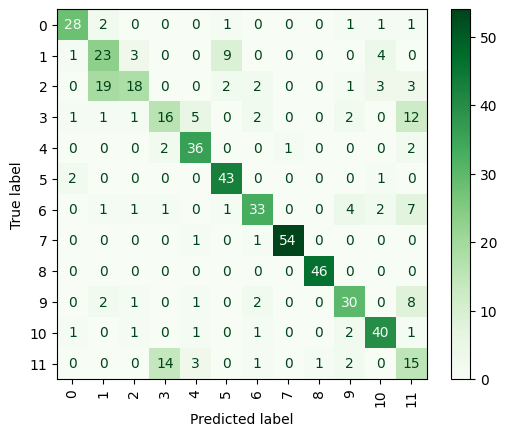

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_2, y_pred_rf_2, labels=rf_2.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_2.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

plt.show()

In [56]:
# # Save the model to a file
joblib.dump(rf_2, "../models/Crop_recommendation_2_randomForest_Classifier_Model.joblib")
print("Random Forest Classifier saved to: models/Crop_recommendation_2_randomForest_Classifier")

Random Forest Classifier saved to: models/Crop_recommendation_2_randomForest_Classifier


In [51]:
#!pip install xgboost

In [52]:
# xg boost
from xgboost import XGBClassifier

# initialise the model
xgb_2 = XGBClassifier(random_state=142)

# Fit the model
xgb_2.fit(X_train_2, y_train_2)

# predict the test set
y_pred_xgb_2 = xgb_2.predict(X_test_2)

In [53]:
# Model Evaluation for XGBoost
print("\nGradient Boosting Machine (XGBoost):")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test_2, y_pred_xgb_2):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test_2, y_pred_xgb_2, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test_2, y_pred_xgb_2, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall.
print(f"F1 Score: {f1_score(y_test_2, y_pred_xgb_2, average='macro'):.4f}")


Gradient Boosting Machine (XGBoost):
Accuracy: 0.7027
Precision: 0.6904
Recall: 0.6965
F1 Score: 0.6914


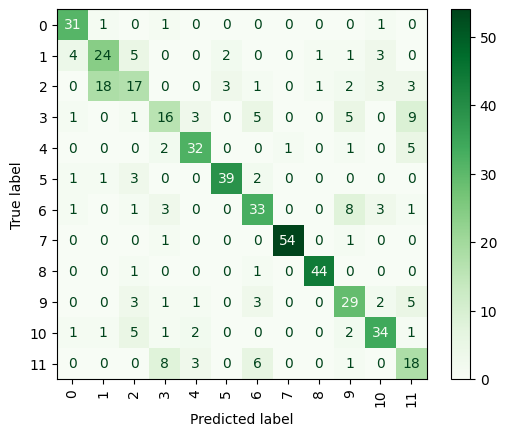

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_2, y_pred_xgb_2, labels=xgb_2.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_2.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

plt.show()

In [55]:
# 1. Define the parameter grid for XGBoost
xgb_param_grid = {
    # Number of boosting rounds
    'n_estimators': [int(x) for x in np.linspace(100, 1000, num=10)],
    # Maximum depth of a tree
    'max_depth': [3, 4, 5, 6, 8, 10, 12, 15],
    # Step size shrinkage used in update to prevent overfitting
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    # Minimum loss reduction required to make a further partition on a leaf node
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    # Subsample ratio of the training instances
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    # Subsample ratio of columns when constructing each tree
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    # Minimum sum of instance weight (hessian) needed in a child
    'min_child_weight': [1, 2, 3, 4]
}

print("XGBoost parameter grid initialized.")

XGBoost parameter grid initialized.


In [56]:
# 2. Initialize the base model
xgb_base = XGBClassifier(random_state=142, use_label_encoder=False, eval_metric='mlogloss')

# 3. Initialize RandomizedSearchCV
# n_iter=50 search across 50 different combinations; cv=3 points to 3-fold cross validation
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Fit the random search model
print("\nStarting Random Search for XGBoost... (This might take a few minutes)")
xgb_random.fit(X_train_2, y_train_2)

# 5. Output the best parameters found
print("\nBest Hyperparameters Found for XGBoost:")
print(xgb_random.best_params_)


Starting Random Search for XGBoost... (This might take a few minutes)
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/opt/anaconda3/envs/kiduka-env/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [00:20:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/kiduka-env/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [00:20:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/kiduka-env/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [00:20:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/kiduka-env/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [00:20:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_

[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=4, n_estimators=200, subsample=0.9; total time=   2.3s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=4, n_estimators=200, subsample=0.9; total time=   2.3s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=4, n_estimators=200, subsample=0.9; total time=   2.4s


/opt/anaconda3/envs/kiduka-env/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [00:20:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/kiduka-env/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [00:20:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/kiduka-env/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [00:20:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.05, max_depth=12, min_child_weight=2, n_estimators=400, subsample=0.8; total time=   4.9s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.05, max_depth=12, min_child_weight=2, n_estimators=400, subsample=0.8; total time=   5.0s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.05, max_depth=12, min_child_weight=2, n_estimators=400, subsample=0.8; total time=   5.1s


...

[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=4, min_child_weight=2, n_estimators=900, subsample=0.8; total time=   5.3s


/opt/anaconda3/envs/kiduka-env/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [00:22:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=4, min_child_weight=2, n_estimators=900, subsample=0.8; total time=   5.4s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=4, min_child_weight=2, n_estimators=900, subsample=0.8; total time=   5.1s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.01, max_depth=8, min_child_weight=2, n_estimators=800, subsample=0.7; total time=  15.4s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.01, max_depth=8, min_child_weight=2, n_estimators=800, subsample=0.7; total time=  15.4s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.01, max_depth=8, min_child_weight=2, n_estimators=800, subsample=0.7; total time=  15.4s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=2, n_estimators=900, subsample=0.6; total time=   6.6s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=2, n_estimators=900, subsample=0.6

/opt/anaconda3/envs/kiduka-env/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [00:22:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=2, n_estimators=900, subsample=0.6; total time=   4.8s

Best Hyperparameters Found for XGBoost:
{'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}


In [57]:
# 6. Evaluate the best model
best_xgb = xgb_random.best_estimator_
y_pred_tuned_xgb = best_xgb.predict(X_test_2)

print("\nTuned XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test_2, y_pred_tuned_xgb):.4f}")
print(f"Precision: {precision_score(y_test_2, y_pred_tuned_xgb, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test_2, y_pred_tuned_xgb, average='macro'):.4f}")
print(f"F1 Score: {f1_score(y_test_2, y_pred_tuned_xgb, average='macro'):.4f}")

print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test_2, y_pred_tuned_xgb))


Tuned XGBoost Results:
Accuracy: 0.7083
Precision: 0.6978
Recall: 0.7004
F1 Score: 0.6957

Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

           0       0.74      0.85      0.79        34
           1       0.52      0.60      0.56        40
           2       0.47      0.38      0.42        48
           3       0.57      0.40      0.47        40
           4       0.78      0.85      0.81        41
           5       0.83      0.83      0.83        46
           6       0.74      0.70      0.72        50
           7       1.00      0.96      0.98        56
           8       0.96      0.98      0.97        46
           9       0.60      0.66      0.63        44
          10       0.79      0.72      0.76        47
          11       0.36      0.47      0.41        36

    accuracy                           0.71       528
   macro avg       0.70      0.70      0.70       528
weighted avg       0.71      0.71      0.71       528



In [ ]:
# # Save the model to a file
# joblib.dump(rf, "models/Soil_Status_xgb_Model.joblib")

# print("Gradient Boosting Classifier saved to: models/Soil_Status_xgb_Classifier")